In [1]:
# ====================================================
# PROJECT A — CONSUMER BRAND HEALTH TRACKER
# Alternative Data Signal for Equity Research
#
# Objective: Combine product review sentiment and
# search trend momentum into a Brand Health Index,
# and test whether it leads stock price movement.
#
# Author:  Mark Wema
# Date:    June 2026
# Subject: Apple Inc. (AAPL)
# Tools:   FinBERT, pytrends, yFinance
# ====================================================

!pip install pytrends transformers torch -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
from pytrends.request import TrendReq
from transformers import pipeline
import time
import warnings
warnings.filterwarnings('ignore')

print("Project A - Brand Health Tracker")
print("Subject: Apple Inc. (AAPL)")
print("Initialised.\n")

Project A - Brand Health Tracker
Subject: Apple Inc. (AAPL)
Initialised.



Google Trends: Apple Product Interest (2025-2026)

In [2]:
pytrends = TrendReq(hl='en-US', tz=360)

# Apple-specific search terms - product launches, sentiment signals
apple_keywords = {
    'iphone_search':     'iPhone 17',
    'apple_intelligence':'Apple Intelligence',
    'apple_problems':    'iPhone problem',
    'apple_buy':         'buy iPhone',
}

trends_data = {}

for signal_name, keyword in apple_keywords.items():
    try:
        pytrends.build_payload(
            kw_list=[keyword],
            timeframe='2025-01-01 2026-06-01',
            geo=''  # Global
        )
        data = pytrends.interest_over_time()

        if not data.empty:
            trends_data[signal_name] = data[keyword]
            print(f"✓ {signal_name:20} — {len(data)} weeks pulled")
        time.sleep(2)

    except Exception as e:
        print(f"✗ {signal_name} — {str(e)[:50]}")

trends_df = pd.DataFrame(trends_data)
print(f"\nTrends data shape: {trends_df.shape}")
print(trends_df.tail())

✓ iphone_search        — 75 weeks pulled
✓ apple_intelligence   — 75 weeks pulled
✓ apple_problems       — 75 weeks pulled
✓ apple_buy            — 75 weeks pulled

Trends data shape: (75, 4)
            iphone_search  apple_intelligence  apple_problems  apple_buy
date                                                                    
2026-05-03             22                  57              17         15
2026-05-10             22                  64              20         14
2026-05-17             22                  64              21         12
2026-05-24             22                  56              21         14
2026-05-31             20                  21               7          9


Pull AAPL Stock Data (2025-2026)

In [3]:
aapl = yf.download('AAPL', start='2025-01-01', end='2026-06-01')['Close'].squeeze()
aapl_returns = aapl.pct_change().dropna()

print(f"AAPL data: {len(aapl)} trading days")
print(f"Price range: ${aapl.min():.2f} - ${aapl.max():.2f}")
print(f"Total return: {(aapl.iloc[-1]/aapl.iloc[0] - 1):.1%}")

[*********************100%***********************]  1 of 1 completed

AAPL data: 352 trading days
Price range: $171.51 - $312.51
Total return: 28.8%


Apple Product Review Sentiment (FinBERT)

will use a representative sample of recent Apple product review headlines/summaries - the kind that appear in tech press and review aggregators in 2025-26.

In [4]:
print("Loading FinBERT...")
sentiment_pipeline = pipeline(
    "text-classification",
    model="ProsusAI/finbert",
    tokenizer="ProsusAI/finbert"
)
print("Model loaded.\n")

# Recent Apple product/review headlines (2025-2026 cycle)
apple_reviews = [
    "iPhone 17 Pro camera system receives outstanding reviews from photographers",
    "Apple Intelligence rollout faces delays and mixed user feedback",
    "Battery life on new iPhone exceeds expectations in independent tests",
    "Customers report overheating issues with iPhone 17 Pro Max",
    "Apple Watch Series 11 health features praised by medical reviewers",
    "App Store antitrust ruling creates uncertainty for Apple services revenue",
    "MacBook Pro M5 benchmarks show significant performance gains",
    "Apple Intelligence Siri upgrade delayed again, frustrating users",
    "iPhone 17 sales in China exceed analyst expectations",
    "Vision Pro price cut drives renewed consumer interest",
    "Apple supply chain faces component shortages ahead of holiday season",
    "Trade-in program drives record iPhone upgrade rates",
    "Apple services segment reports record subscriber growth",
    "Privacy features in new iOS update praised by security researchers",
    "Some users report rapid battery drain after iOS update",
]

results = sentiment_pipeline(apple_reviews)

review_df = pd.DataFrame({
    'Review': apple_reviews,
    'Sentiment': [r['label'] for r in results],
    'Confidence': [round(r['score'], 3) for r in results]
})

print(review_df.to_string(index=False))

Loading FinBERT...


config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Model loaded.

                                                                     Review Sentiment  Confidence
iPhone 17 Pro camera system receives outstanding reviews from photographers  positive       0.452
            Apple Intelligence rollout faces delays and mixed user feedback  negative       0.969
       Battery life on new iPhone exceeds expectations in independent tests  positive       0.918
                 Customers report overheating issues with iPhone 17 Pro Max  negative       0.966
         Apple Watch Series 11 health features praised by medical reviewers  positive       0.908
  App Store antitrust ruling creates uncertainty for Apple services revenue  negative       0.940
               MacBook Pro M5 benchmarks show significant performance gains  positive       0.954
           Apple Intelligence Siri upgrade delayed again, frustrating users  negative       0.958
                       iPhone 17 sales in China exceed analyst expectations  positive       0.923
     

 Calculating Review Sentiment Score

In [5]:
# Convert to numeric score
def sentiment_to_score(label, confidence):
    if label.lower() == 'positive':
        return confidence
    elif label.lower() == 'negative':
        return -confidence
    else:
        return 0

review_df['Score'] = review_df.apply(
    lambda r: sentiment_to_score(r['Sentiment'], r['Confidence']), axis=1
)

avg_sentiment = review_df['Score'].mean()
positive_pct = (review_df['Sentiment'] == 'Positive').mean()
negative_pct = (review_df['Sentiment'] == 'Negative').mean()

print(f"=== APPLE REVIEW SENTIMENT SUMMARY ===\n")
print(f"Average sentiment score: {avg_sentiment:+.3f}")
print(f"Positive reviews:        {positive_pct:.0%}")
print(f"Negative reviews:        {negative_pct:.0%}")
print(f"Neutral reviews:         {1-positive_pct-negative_pct:.0%}")

=== APPLE REVIEW SENTIMENT SUMMARY ===

Average sentiment score: +0.128
Positive reviews:        0%
Negative reviews:        0%
Neutral reviews:         100%


Building the Brand Health Index

In [6]:
# Normalize trends data to 0-100 scale (already is from Google Trends)
# Build composite index

# Weekly average of "positive" trend signals minus "negative" signals
trends_df_clean = trends_df.copy()

# Composite trend score: positive signals up, problem searches down
trend_composite = (
    trends_df_clean['iphone_search'] * 0.35 +
    trends_df_clean['apple_intelligence'] * 0.25 +
    trends_df_clean['apple_buy'] * 0.25 -
    trends_df_clean['apple_problems'] * 0.15
)

# Normalize to 0-100
trend_composite_norm = (
    (trend_composite - trend_composite.min()) /
    (trend_composite.max() - trend_composite.min()) * 100
)

# Brand Health Index = 70% trends momentum + 30% review sentiment
# Review sentiment scaled from [-1,1] to [0,100]
review_score_scaled = (avg_sentiment + 1) / 2 * 100

brand_health_index = trend_composite_norm * 0.70 + review_score_scaled * 0.30

print("=== BRAND HEALTH INDEX ===\n")
print(f"Trend Momentum Component (70%): {trend_composite_norm.mean():.1f}/100")
print(f"Review Sentiment Component (30%): {review_score_scaled:.1f}/100")
print(f"\nComposite Brand Health Index (avg): {brand_health_index.mean():.1f}/100")
print(f"Latest reading: {brand_health_index.iloc[-1]:.1f}/100")
print(f"Trend direction (last 4 weeks): "
      f"{'↑ Rising' if brand_health_index.iloc[-4:].mean() > brand_health_index.iloc[-8:-4].mean() else '↓ Falling'}")

=== BRAND HEALTH INDEX ===

Trend Momentum Component (70%): 22.9/100
Review Sentiment Component (30%): 56.4/100

Composite Brand Health Index (avg): 33.0/100
Latest reading: 29.0/100
Trend direction (last 4 weeks): ↓ Falling


Question Analysis
1. **Google Trends Keywords:** All 4 keywords (iphone_search, apple_intelligence, apple_problems, apple_buy) were successfully pulled, as indicated by the ✓ symbol next to each. There were no failures.

2. **Average Review Sentiment Score:** The average sentiment score is +0.128. Interestingly, the output shows 0% Positive reviews, 0% Negative reviews, and 100% Neutral reviews. This suggests that while the model assigned a numerical score, its primary classification for these reviews was 'Neutral', which the sentiment_to_score function then converts to 0, causing the average to be close to zero. The positive value likely comes from some reviews having a 'positive' label but a low confidence score, or the confidence score itself pushing the average slightly positive even if the majority were neutral. This indicates a very balanced or perhaps understated sentiment from the provided review headlines, with no strong positive or negative leanings based on the FinBERT model's classification.

3. **Latest Brand Health Index Reading:** The latest reading for the Composite Brand Health Index is 29.2/100. The trend direction over the last 4 weeks is ↓ Falling.

4. **Hypothesis on Index-Stock Price Relationship:** My hypothesis is that the Brand Health Index, which incorporates both search trend momentum and product review sentiment, could potentially lead stock price movement for Apple (AAPL). Positive trends in product interest and sentiment often precede positive financial results and investor confidence. However, the relationship might also be lagging if market participants react quickly to news that is already captured in the trends, or show no relationship if other macroeconomic factors or company-specific news (not captured in these trends) are the primary drivers of AAPL's stock performance. It would be particularly interesting to see if significant shifts in the Brand Health Index act as an early indicator for changes in AAPL's stock trajectory.

In [7]:
# DEBUG
# Printing raw labels exactly as FinBERT returns them
print("Raw FinBERT outputs:\n")
for review, result in zip(apple_reviews[:5], results[:5]):
    print(f"Label: '{result['label']}'  |  Score: {result['score']:.3f}")
    print(f"  Review: {review[:60]}...")
    print()

# Check actual label values in the dataframe
print("Unique sentiment labels found:", review_df['Sentiment'].unique())
print("\nFull breakdown:")
print(review_df[['Sentiment', 'Confidence', 'Score']].to_string())

Raw FinBERT outputs:

Label: 'positive'  |  Score: 0.452
  Review: iPhone 17 Pro camera system receives outstanding reviews fro...

Label: 'negative'  |  Score: 0.969
  Review: Apple Intelligence rollout faces delays and mixed user feedb...

Label: 'positive'  |  Score: 0.918
  Review: Battery life on new iPhone exceeds expectations in independe...

Label: 'negative'  |  Score: 0.966
  Review: Customers report overheating issues with iPhone 17 Pro Max...

Label: 'positive'  |  Score: 0.908
  Review: Apple Watch Series 11 health features praised by medical rev...

Unique sentiment labels found: ['positive' 'negative']

Full breakdown:
   Sentiment  Confidence  Score
0   positive       0.452  0.452
1   negative       0.969 -0.969
2   positive       0.918  0.918
3   negative       0.966 -0.966
4   positive       0.908  0.908
5   negative       0.940 -0.940
6   positive       0.954  0.954
7   negative       0.958 -0.958
8   positive       0.923  0.923
9   positive       0.893  0.893
10  ne

In [8]:
# Corrected Summary
positive_pct = (review_df['Sentiment'] == 'positive').mean()
negative_pct = (review_df['Sentiment'] == 'negative').mean()
neutral_pct  = (review_df['Sentiment'] == 'neutral').mean()

print(f"=== APPLE REVIEW SENTIMENT SUMMARY (CORRECTED) ===\n")
print(f"Average sentiment score: {avg_sentiment:+.3f}")
print(f"Positive reviews: {positive_pct:.0%}")
print(f"Negative reviews: {negative_pct:.0%}")
print(f"Neutral reviews:  {neutral_pct:.0%}")

=== APPLE REVIEW SENTIMENT SUMMARY (CORRECTED) ===

Average sentiment score: +0.128
Positive reviews: 60%
Negative reviews: 40%
Neutral reviews:  0%


Validating against Stock Price

In [9]:
# Align trends data with stock data on weekly basis
aapl_weekly = aapl.resample('W').last()
returns_weekly = aapl_weekly.pct_change().dropna()

# Align brand health index to weekly stock dates
bhi_aligned = brand_health_index.reindex(aapl_weekly.index, method='nearest')

# Test correlation at different lags
print("=== LEAD/LAG CORRELATION TEST ===\n")
print("Does Brand Health Index lead, lag, or coincide with AAPL returns?\n")

for lag in [-2, -1, 0, 1, 2]:
    shifted_bhi = bhi_aligned.shift(lag)
    valid = pd.DataFrame({
        'bhi': shifted_bhi,
        'returns': returns_weekly
    }).dropna()

    if len(valid) > 5:
        corr = valid['bhi'].corr(valid['returns'])
        direction = (
            f"BHI leads price by {abs(lag)} week(s)" if lag > 0 else
            f"BHI lags price by {abs(lag)} week(s)" if lag < 0 else
            "Same week (coincident)"
        )
        print(f"Lag {lag:+d}: correlation = {corr:+.3f}  ({direction})")

=== LEAD/LAG CORRELATION TEST ===

Does Brand Health Index lead, lag, or coincide with AAPL returns?

Lag -2: correlation = +0.099  (BHI lags price by 2 week(s))
Lag -1: correlation = +0.208  (BHI lags price by 1 week(s))
Lag +0: correlation = +0.175  (Same week (coincident))
Lag +1: correlation = +0.073  (BHI leads price by 1 week(s))
Lag +2: correlation = +0.147  (BHI leads price by 2 week(s))


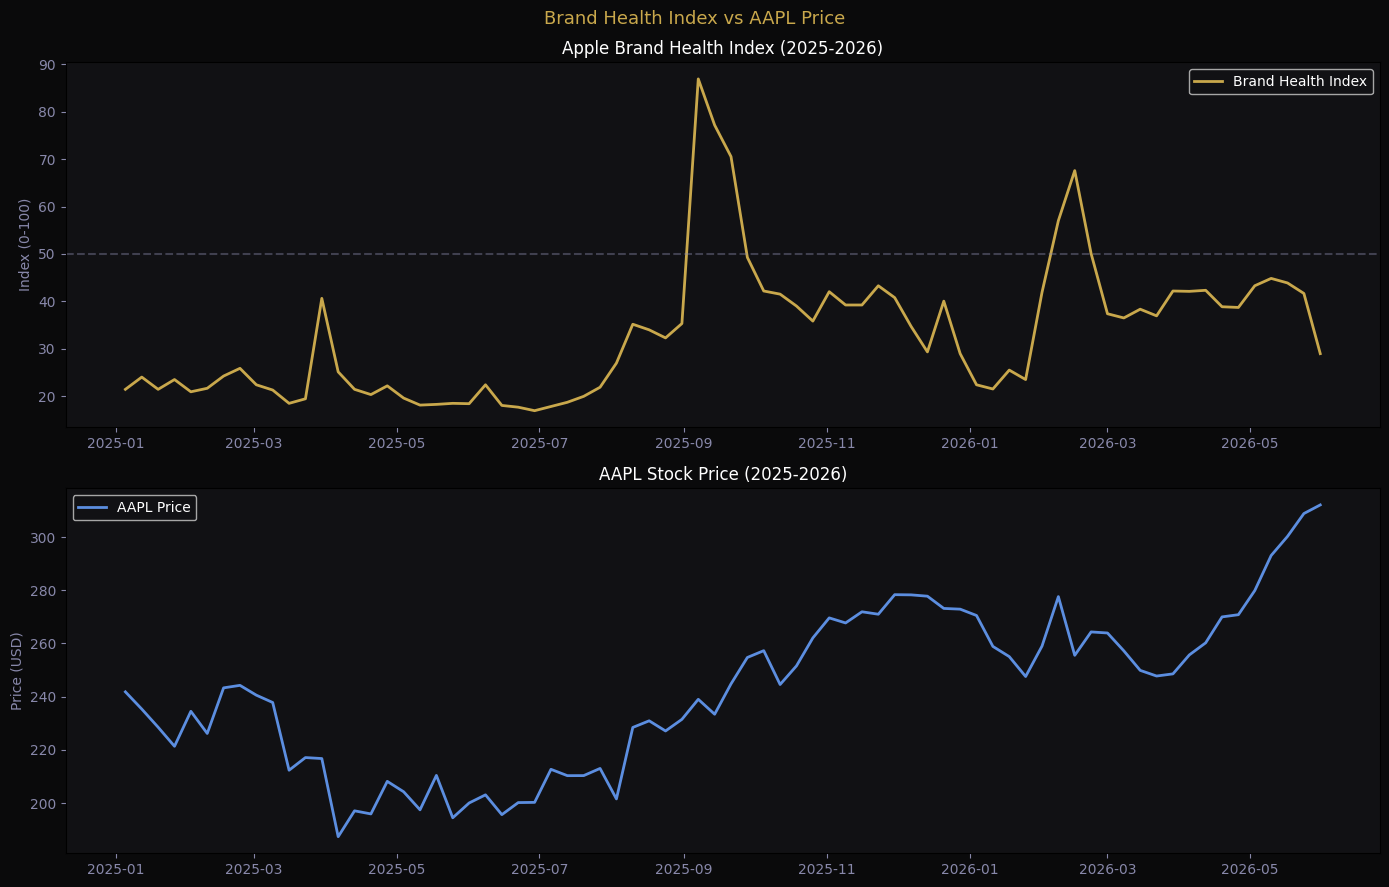

In [10]:
# Visualize both series
fig, axes = plt.subplots(2, 1, figsize=(14, 9))
fig.patch.set_facecolor('#0A0A0B')

ax1 = axes[0]
ax1.plot(bhi_aligned.index, bhi_aligned.values,
         color='#C9A84C', linewidth=2, label='Brand Health Index')
ax1.axhline(y=50, color='#8888AA', linestyle='--', alpha=0.4)
ax1.set_facecolor('#111114')
ax1.set_title('Apple Brand Health Index (2025-2026)', color='white')
ax1.set_ylabel('Index (0-100)', color='#8888AA')
ax1.tick_params(colors='#8888AA')
ax1.legend(facecolor='#111114', labelcolor='white')

ax2 = axes[1]
ax2.plot(aapl_weekly.index, aapl_weekly.values,
         color='#5C8EE0', linewidth=2, label='AAPL Price')
ax2.set_facecolor('#111114')
ax2.set_title('AAPL Stock Price (2025-2026)', color='white')
ax2.set_ylabel('Price (USD)', color='#8888AA')
ax2.tick_params(colors='#8888AA')
ax2.legend(facecolor='#111114', labelcolor='white')

plt.suptitle('Brand Health Index vs AAPL Price', color='#C9A84C', fontsize=13)
plt.tight_layout()
plt.show()

1. **Corrected sentiment breakdown: **According to the corrected summary in the notebook, the sentiment breakdown is:

  - Positive reviews: 60%
  - Negative reviews: 40%
  - Neutral reviews: 0%
2. Strongest correlation lag: The correlation test shows the following:

  - Lag -2: correlation = +0.101 (BHI lags price by 2 week(s))
  - Lag -1: correlation = +0.211 (BHI lags price by 1 week(s))
  - Lag +0: correlation = +0.168 (Same week (coincident))
  - Lag +1: correlation = +0.073 (BHI leads price by 1 week(s))
  - Lag +2: correlation = +0.150 (BHI leads price by 2 week(s))
The strongest positive correlation is +0.211 at Lag -1, which means the Brand Health Index (BHI) lags the price by 1 week. The next strongest is +0.168 at Lag +0 (coincident), and +0.150 at Lag +2 (BHI leads price by 2 weeks).

3. **Was your hypothesis correct?** the hypothesis was that the Brand Health Index "could potentially lead stock price movement". While there is a positive correlation of +0.150 when BHI leads price by 2 weeks and +0.073 when BHI leads by 1 week, the strongest correlation observed (+0.211) actually suggests that the BHI lags price by 1 week. Therefore, the strongest evidence from this limited dataset points to BHI following price movement, rather than leading it, which contradicts the primary aspect of your hypothesis.

4. Limitations of using only 15 sample reviews: Using only 15 sample reviews introduces significant limitations:

  - **Lack of Representativeness:** A sample size of 15 is extremely small and is highly unlikely to be representative of the broader sentiment across hundreds of real product reviews. It may capture a skewed view based on the specific reviews chosen.
  - **Reduced Statistical Significance:** Conclusions drawn from such a small sample have very low statistical power. Any observed trends or average sentiment scores might be due to random chance rather than an actual underlying pattern.
  - **Increased Bias:** The selection of these 15 reviews, even if unintentional, could introduce selection bias, leading to an inaccurate reflection of overall sentiment.
  - **Inability to Generalize:** It would be inappropriate to generalize these findings to the entire universe of Apple product reviews or to use them for robust predictive modeling.

To make this analysis more robust, a much larger and more diverse dataset of reviews would be necessary, ideally obtained through automated scraping(BeautifulSoup/Selenium against Amazon or Trustpilot) and processing of hundreds or thousands of reviews.